<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **SpaceX  Falcon 9 First Stage Landing Prediction**


 ## Hands-on Lab: Complete the EDA with Visualization


Estimated time needed: **70** minutes


In this assignment, we will predict if the Falcon 9 first stage will land successfully. SpaceX advertises Falcon 9 rocket launches on its website with a cost of 62 million dollars; other providers cost upward of 165 million dollars each, much of the savings is due to the fact that SpaceX can reuse the first stage. 

In this lab, you will perform Exploratory Data Analysis and Feature Engineering.


Falcon 9 first stage will land successfully


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


Most unsuccessful landings are planned. Space X performs a controlled landing in the oceans. 


  ## Objectives
Perform exploratory Data Analysis and Feature Engineering using `Pandas` and `Matplotlib`

- Exploratory Data Analysis
- Preparing Data  Feature Engineering 


----


Install the below libraries


In [1]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib

### Import Libraries and Define Auxiliary Functions


We will import the following libraries the lab 



In [4]:
# andas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns

## Exploratory Data Analysis 


First, let's read the SpaceX dataset into a Pandas dataframe and print its summary


Analyse exploratoire des données

Commençons par importer le jeu de données SpaceX dans un dataframe Pandas et affichons son résumé.

In [5]:
df=pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# If you were unable to complete the previous lab correctly you can uncomment and load this csv

# df = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/dataset_part_2.csv')

df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


First, let's try to see how the `FlightNumber` (indicating the continuous launch attempts.) and `Payload` variables would affect the launch outcome.

We can plot out the <code>FlightNumber</code> vs. <code>PayloadMass</code>and overlay the outcome of the launch. We see that as the flight number increases, the first stage is more likely to land successfully. The payload mass is also important; it seems the more massive the payload, the less likely the first stage will return.

Tout d'abord, examinons l'influence du numéro de vol (indiquant le nombre de tentatives de lancement) et de la masse de la charge utile sur le résultat du lancement.

Nous pouvons tracer le graphique du numéro de vol en fonction de la masse de la charge utile et y superposer le résultat du lancement. On constate que plus le numéro de vol est élevé, plus la probabilité d'atterrissage réussi du premier étage augmente. La masse de la charge utile est également importante ; il semble que plus elle est massive, moins le premier étage a de chances de revenir.

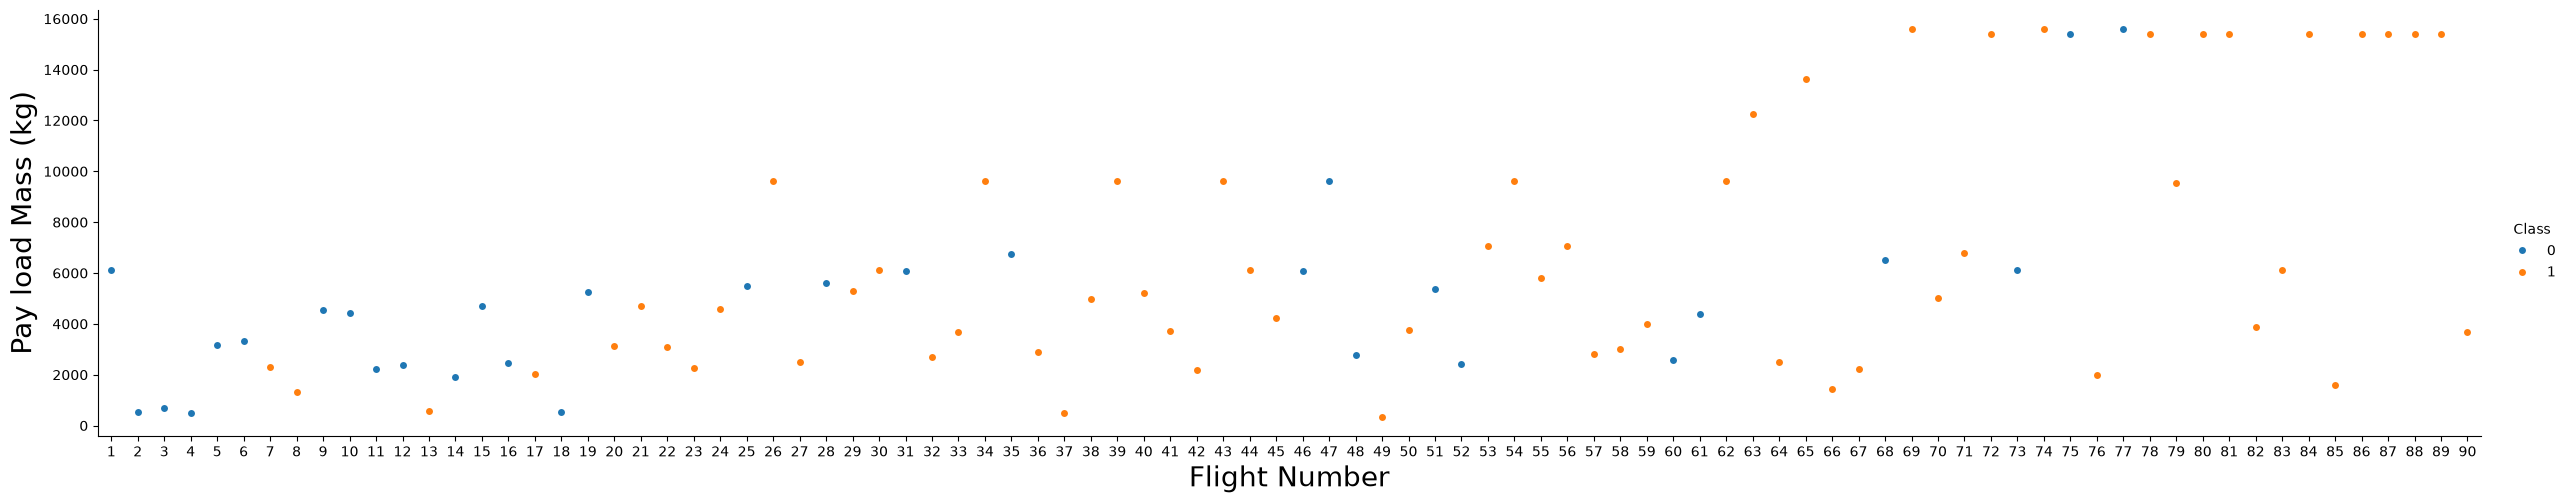

In [6]:
sns.catplot(y="PayloadMass", x="FlightNumber", hue="Class", data=df, aspect = 5)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Pay load Mass (kg)",fontsize=20)
plt.show()

Next, let's drill down to each site visualize its detailed launch records.

Ensuite, examinons chaque site en détail et visualisons ses historiques de lancement.

### TASK 1: Visualize the relationship between Flight Number and Launch Site



Use the function <code>catplot</code> to plot <code>FlightNumber</code> vs <code>LaunchSite</code>, set the  parameter <code>x</code>  parameter to <code>FlightNumber</code>,set the  <code>y</code> to <code>Launch Site</code> and set the parameter <code>hue</code> to <code>'class'</code>


TÂCHE 1 : Visualiser la relation entre le numéro de vol et le site de lancement
Utilisez la fonction catplot pour tracer le graphique du numéro de vol en fonction du site de lancement. Définissez le paramètre x sur le numéro de vol, le paramètre y sur le site de lancement et le paramètre hue sur « class ».

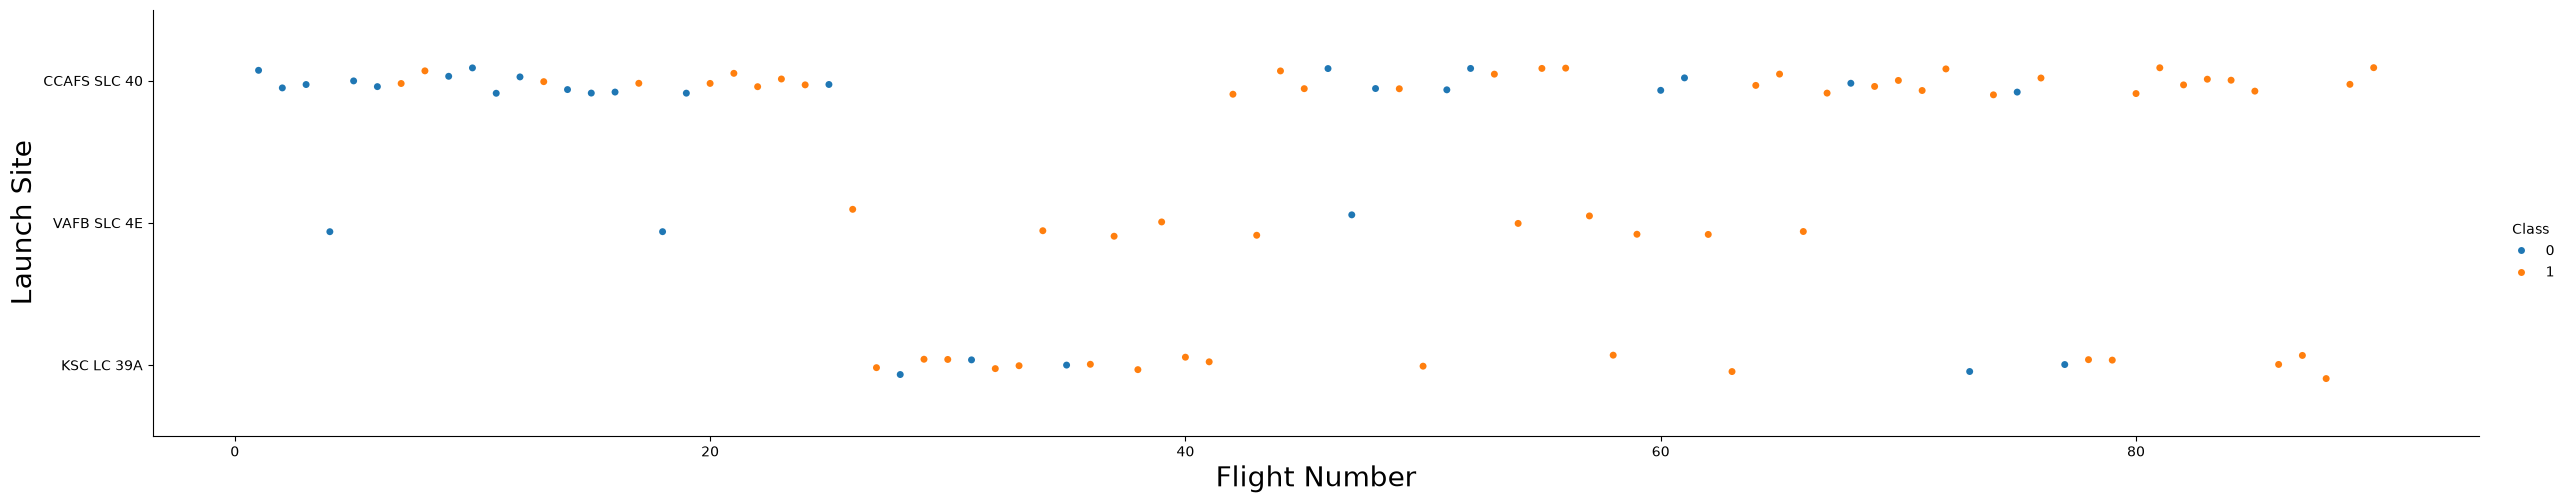

In [7]:
# Plot a scatter point chart with x axis to be Flight Number and y axis to be the launch site, and hue to be the class value
#import matplotlib.pyplot as plt
#import seaborn as sns

# Code pour tracer la relation entre Flight Number et Launch Site
sns.catplot(x="FlightNumber", y="LaunchSite", hue="Class", data=df, aspect=5)

# Configuration des étiquettes des axes
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)

# Affichage du graphique
plt.show()



Now try to explain the patterns you found in the Flight Number vs. Launch Site scatter point plots.

Essayez maintenant d'expliquer les tendances que vous avez observées dans les graphiques de dispersion « Numéro de vol vs. Site de lancement ».

Explication : L'examen des graphiques de dispersion « Numéro de vol vs. Site de lancement » révèle une tendance claire concernant la fréquence des lancements depuis différentes sites. Il est généralement observé que certains sites de lancement sont associés à un nombre de vols significativement plus élevé que d'autres. Cette observation suggère une spécialisation ou une importance stratégique accrue de ces sites dans les opérations spatiales.

### TASK 2: Visualize the relationship between Payload and Launch Site


We also want to observe if there is any relationship between launch sites and their payload mass.


TÂCHE 2 : Visualiser la relation entre la charge utile et le site de lancement

Nous souhaitons également observer s’il existe une relation entre les sites de lancement et la masse de leur charge utile.

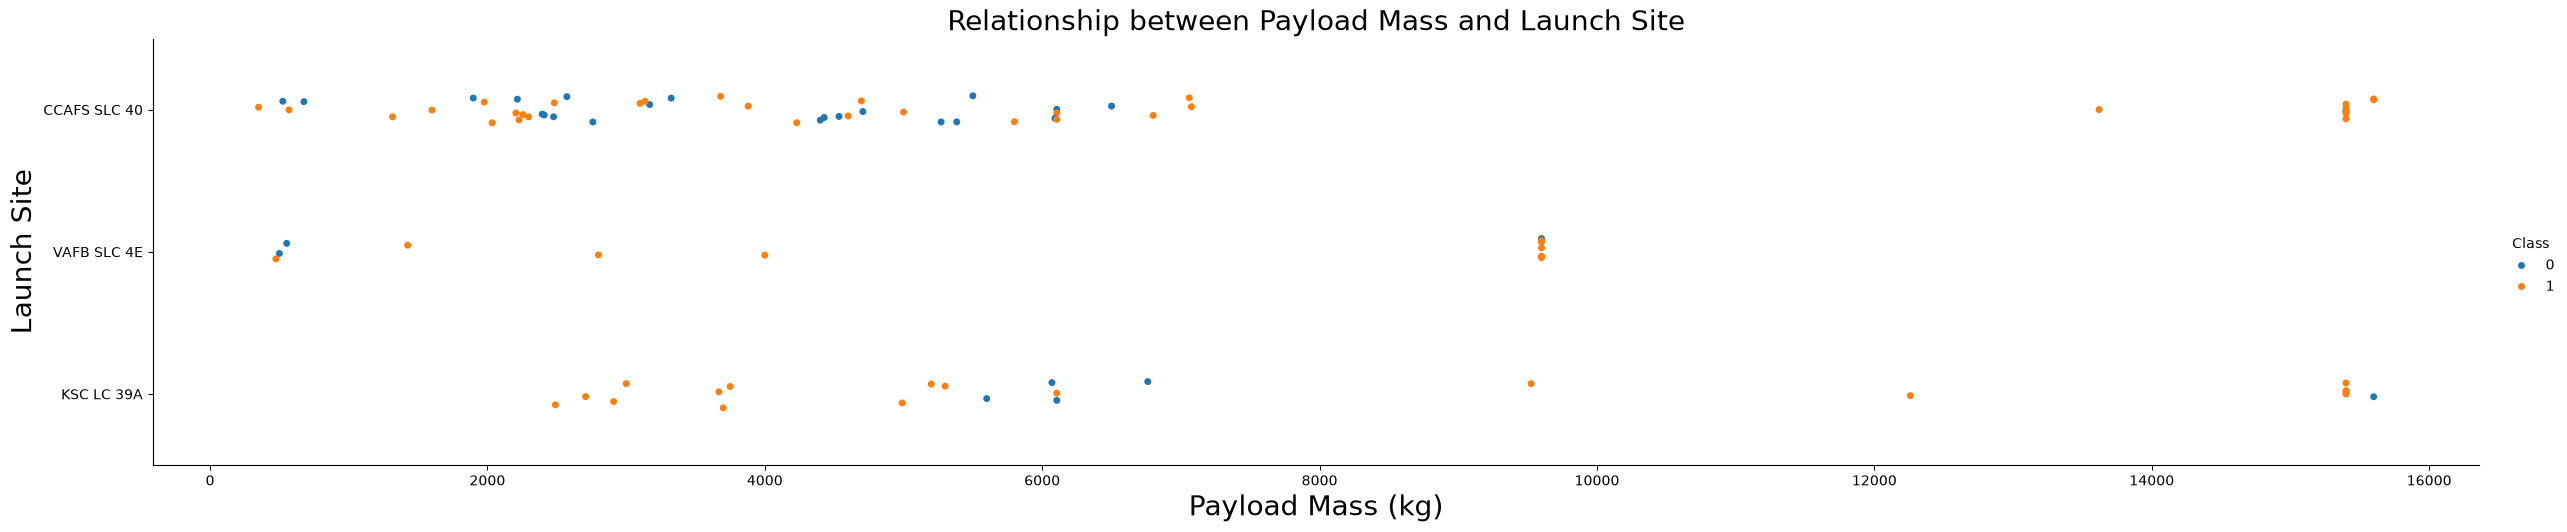

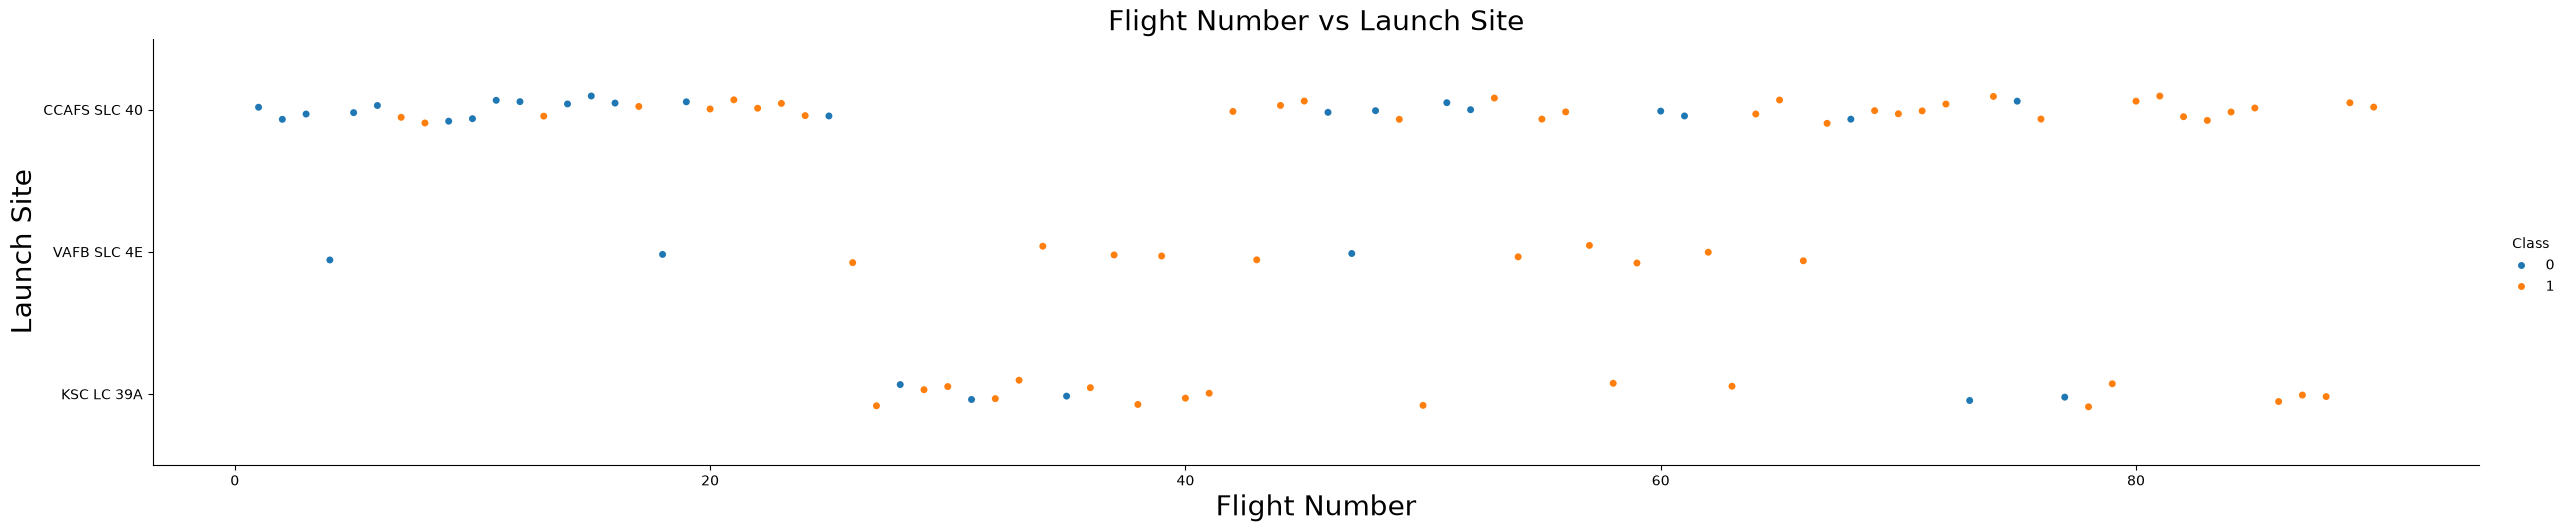

In [21]:
# Plot a scatter point chart with x axis to be Pay Load Mass (kg) and y axis to be the launch site, and hue to be the class value

# -- TASK 2: Relation entre la masse de la charge utile (Payload) et le site de lancement --
# Graphique en nuage de points (Scatter chart) : Charge utile vs Site de lancement
sns.catplot(
    x="PayloadMass",  # Axe X représentant la masse de la charge utile en kg
    y="LaunchSite",  # Axe Y représentant le site de lancement
    hue="Class",  # Coloration selon le résultat (0 = Échec, 1 = Succès)
    data=df,  # Votre DataFrame pandas contenant les données de SpaceX
    aspect=5,  # Ajustement de la largeur du graphique pour une meilleure lisibilité
)

# Configuration des étiquettes et affichage du graphique
plt.xlabel("Payload Mass (kg)", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)
plt.title("Relationship between Payload Mass and Launch Site", fontsize=20)
plt.show()


# -- Complément : FlightNumber vs LaunchSite --
# Graphique demandé dans votre description textuelle
sns.catplot(
    x="FlightNumber",  # Axe X représentant le numéro de vol
    y="LaunchSite",  # Axe Y représentant le site de lancement
    hue="Class",  # Coloration selon la classe de succès
    data=df,
    aspect=5,
)

# Configuration des étiquettes et affichage
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)
plt.title("Flight Number vs Launch Site", fontsize=20)
plt.show()


Now if you observe Payload Vs. Launch Site scatter point chart you will find for the VAFB-SLC  launchsite there are no  rockets  launched for  heavypayload mass(greater than 10000).


Si vous observez le graphique de dispersion de la charge utile en fonction du site de lancement, vous constaterez que pour le site de lancement VAFB-SLC, aucune fusée n'a été lancée pour une masse de charge utile importante (supérieure à 10 000).

### TASK  3: Visualize the relationship between success rate of each orbit type


Next, we want to visually check if there are any relationship between success rate and orbit type.


Let's create a `bar chart` for the sucess rate of each orbit


TÂCHE 3 : Visualiser la relation entre le taux de réussite et le type d’orbite

Nous allons maintenant vérifier visuellement s’il existe une relation entre le taux de réussite et le type d’orbite.

Créons un graphique à barres représentant le taux de réussite de chaque orbite.

/tmp/ipykernel_1950/215695497.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Orbit', y='Class', data=df_orbit, palette='Blues_r')


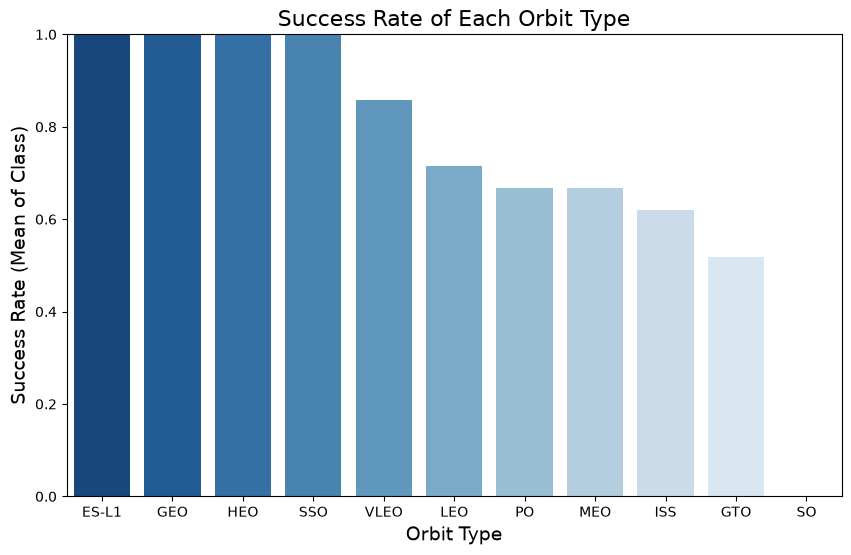

In [22]:
# HINT use groupby method on Orbit column and get the mean of Class column

# 1. Calculer le taux de succès moyen pour chaque type d'orbite
# Le reset_index() transforme le résultat de l'agrégation en un DataFrame propre
df_orbit = df.groupby('Orbit')['Class'].mean().reset_index()

# 2. Trier par taux de succès décroissant pour une meilleure lisibilité
df_orbit = df_orbit.sort_values(by='Class', ascending=False)

# 3. Créer le graphique à barres
plt.figure(figsize=(10, 6))
sns.barplot(x='Orbit', y='Class', data=df_orbit, palette='Blues_r')

# 4. Personnaliser les étiquettes et le titre
plt.title('Success Rate of Each Orbit Type', fontsize=16)
plt.xlabel('Orbit Type', fontsize=14)
plt.ylabel('Success Rate (Mean of Class)', fontsize=14)

# 5. Fixer la limite de l'axe Y de 0 à 1 (représentant 0% à 100%)
plt.ylim(0, 1)

# 6. Afficher le graphique
plt.show()


Analyze the ploted bar chart try to find which orbits have high sucess rate.

Analysez le graphique à barres tracé et essayez de trouver quelles orbites ont un taux de réussite élevé.

Les orbites ayant un taux élevé de réussite sont ES-L1, GEO, SSO et VLEO.

### TASK  4: Visualize the relationship between FlightNumber and Orbit type


For each orbit, we want to see if there is any relationship between FlightNumber and Orbit type.


TÂCHE 4 : Visualiser la relation entre le numéro de vol et le type d’orbite

Pour chaque orbite, nous voulons voir s’il existe une relation entre le numéro de vol et le type d’orbite.

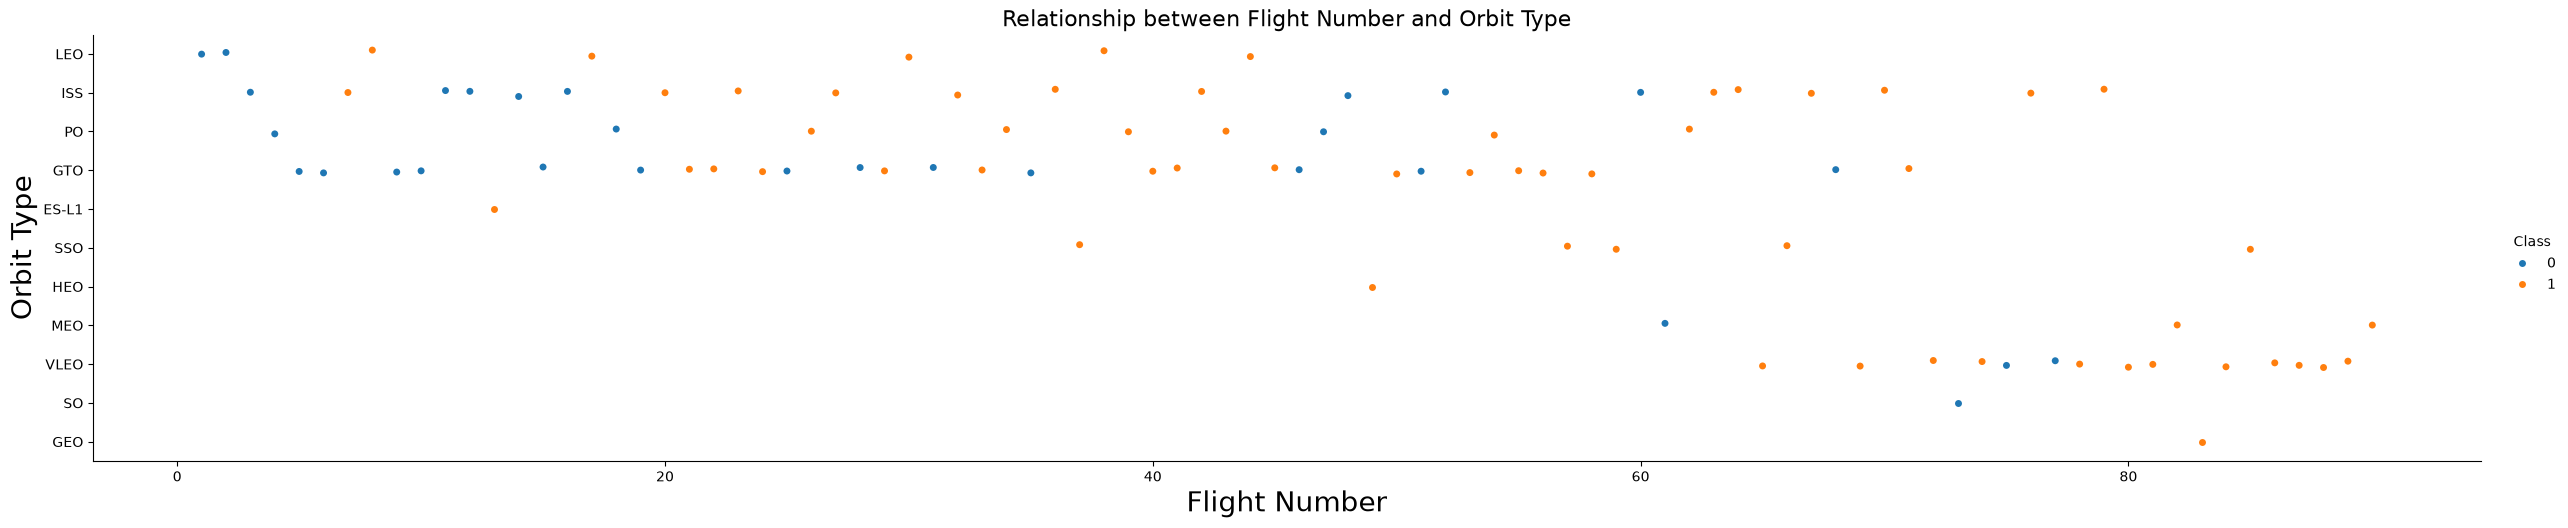

In [11]:
# Plot a scatter point chart with x axis to be FlightNumber and y axis to be the Orbit, and hue to be the class value

# TASK 4: Visualiser la relation entre le numéro de vol (FlightNumber) et le type d'orbite (Orbit)
# Tracé d'un graphique en nuage de points (scatter/categorical plot)
sns.catplot(
    x="FlightNumber", 
    y="Orbit", 
    hue="Class",      # La couleur varie selon la valeur de la classe (0 ou 1)
    data=df,          # Remplacez 'df' par le nom de votre DataFrame si nécessaire
    aspect=5          # Ajuste la largeur pour mieux étaler les points le long de l'axe X
)

# Configuration des étiquettes des axes
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Orbit Type", fontsize=20)
plt.title("Relationship between Flight Number and Orbit Type", fontsize=16)

# Affichage du graphique
plt.show()


You should see that in the LEO orbit the Success appears related to the number of flights; on the other hand, there seems to be no relationship between flight number when in GTO orbit.

Vous constaterez qu'en orbite LEO, le succès semble lié au nombre de vols ; en revanche, il ne semble y avoir aucune relation entre le nombre de vols et le succès en orbite GTO.

### TASK  5: Visualize the relationship between Payload and Orbit type


Similarly, we can plot the Payload vs. Orbit scatter point charts to reveal the relationship between Payload and Orbit type


TÂCHE 5 : Visualiser la relation entre la charge utile et le type d’orbite

De même, nous pouvons tracer des graphiques de dispersion représentant la charge utile en fonction du type d’orbite afin de révéler la relation entre ces deux variables.

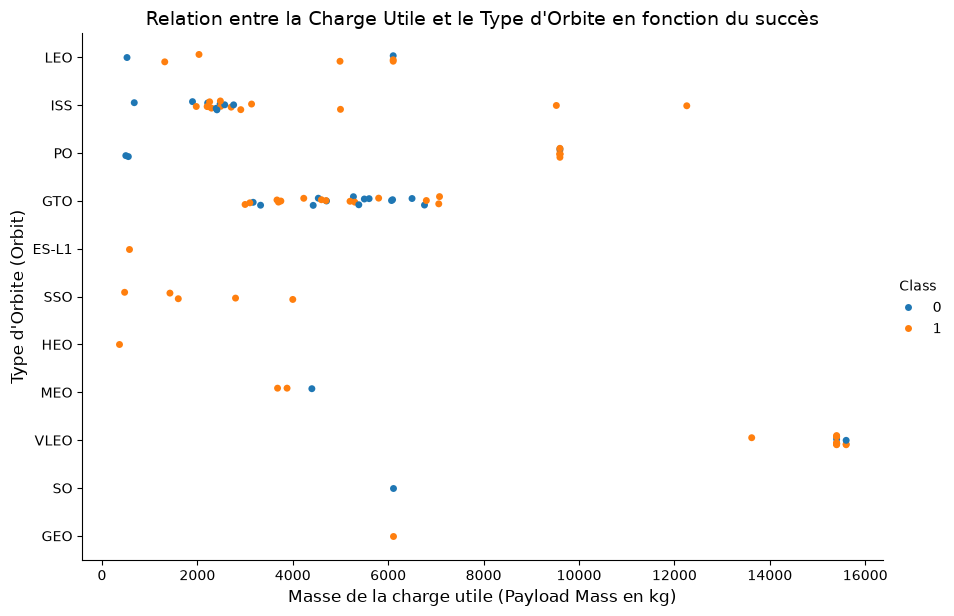

In [13]:
# Plot a scatter point chart with x axis to be Payload and y axis to be the Orbit, and hue to be the class value

# TASK 5: Visualisation de la relation entre la masse de la charge utile (Payload) et le type d'orbite
# Graphique de type nuage de points (scatter plot) 
# Axe X : PayloadMass, Axe Y : Orbit, Couleur (hue) : Class
sns.catplot(
    x="PayloadMass", 
    y="Orbit", 
    hue="Class", 
    data=df, 
    aspect=1.5, 
    height=6
)

# Configuration des étiquettes des axes et du titre
plt.xlabel("Masse de la charge utile (Payload Mass en kg)", fontsize=12)
plt.ylabel("Type d'Orbite (Orbit)", fontsize=12)
plt.title("Relation entre la Charge Utile et le Type d'Orbite en fonction du succès", fontsize=14)

# Affichage du graphique
plt.show()


With heavy payloads the successful landing or positive landing rate are more for Polar,LEO and ISS.   

However for GTO we cannot distinguish this well as both positive landing rate and negative landing(unsuccessful mission) are both there here.


Avec des charges utiles importantes, le taux de réussite des atterrissages est plus élevé pour les orbites polaires, l'orbite terrestre basse (LEO) et l'ISS.

Cependant, pour l'orbite de transfert géostationnaire (GTO), il est plus difficile de faire une distinction nette, car on observe à la fois des taux de réussite et des taux d'échec (missions infructueuses).

### TASK  6: Visualize the launch success yearly trend


You can plot a line chart with x axis to be <code>Year</code> and y axis to be average success rate, to get the average launch success trend. 


The function will help you get the year from the date:

TÂCHE 6 : Visualiser l’évolution annuelle du succès des lancements

Vous pouvez tracer un graphique linéaire avec l’année en abscisse et le taux de réussite moyen en ordonnée, afin d’obtenir l’évolution moyenne du succès des lancements.

La fonction vous permettra d’obtenir l’année à partir de la date.

In [14]:
# A function to Extract years from the date 
year=[]
def Extract_year(date):
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year
    

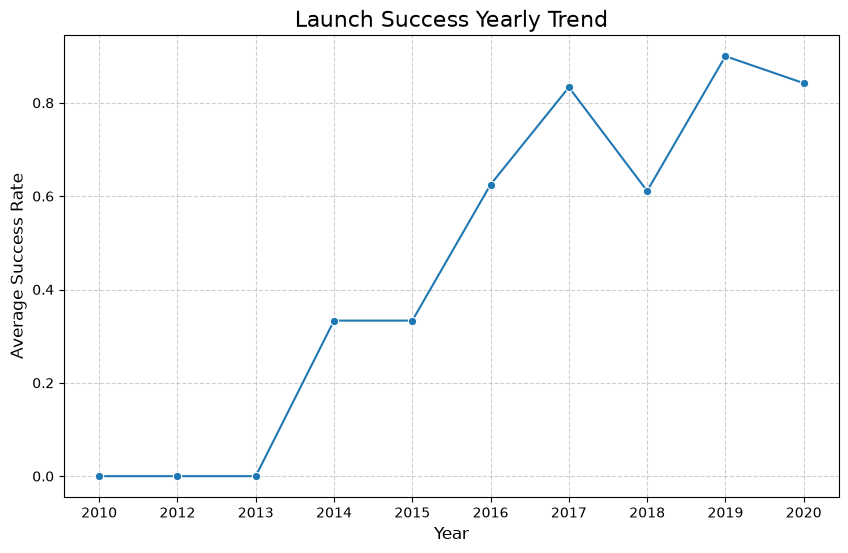

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Définition de la fonction pour extraire l'année
year = []


def Extract_year():
    for i in df["Date"]:
        year.append(str(i).split("-")[0])
    return year


# 2. Application de la fonction pour créer la colonne 'Year'
# On réinitialise la liste 'year' au cas où le code est exécuté plusieurs fois
year = []
Extract_year()
df["Year"] = year

# 3. Calcul du taux moyen de succès par année
# La colonne du taux de succès s'appelle généralement 'Class' dans ce dataset
df_yearly_success = df.groupby("Year")["Class"].mean().reset_index()

# 4. Tracer le graphique linéaire de la tendance annuelle
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_yearly_success, x="Year", y="Class", marker="o")

# 5. Personnalisation des axes et du titre
plt.title("Launch Success Yearly Trend", fontsize=16)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Average Success Rate", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

# Affichage du graphique
plt.show()


You can observe that the success rate since 2013 kept increasing till 2017 (stable in 2014) and after 2015 it started increasing.

On peut observer que le taux de réussite a continué d'augmenter depuis 2013 jusqu'en 2017 (stable en 2014) et qu'il a commencé à augmenter après 2015.

## Features Engineering 
Ingénierie des fonctionnalités

By now, you should obtain some preliminary insights about how each important variable would affect the success rate, we will select the features that will be used in success prediction in the future module.

Vous devriez maintenant avoir une première idée de la façon dont chaque variable importante influence le taux de réussite ; nous sélectionnerons les caractéristiques qui seront utilisées pour la prédiction du succès dans le module suivant.

In [17]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


 ### TASK  7: Create dummy variables to categorical columns


Use the function <code>get_dummies</code> and <code>features</code> dataframe to apply OneHotEncoder to the column <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code>, and <code>Serial</code>. Assign the value to the variable <code>features_one_hot</code>, display the results using the method head. Your result dataframe must include all features including the encoded ones.


TÂCHE 7 : Créer des variables indicatrices pour les colonnes catégorielles

Utilisez la fonction `get_dummies` et le dataframe `features` pour appliquer l’encodage OneHotEncoder aux colonnes `Orbits`, `LaunchSite`, `LandingPad` et `Serial`. Attribuez la valeur à la variable `features_one_hot` et affichez les résultats avec la méthode `head`. Votre dataframe de résultats doit inclure toutes les variables, y compris celles encodées.

In [19]:
# HINT: Use get_dummies() function on the categorical columns

import pandas as pd

# Application du OneHotEncoder avec get_dummies sur les colonnes spécifiées
features_one_hot = pd.get_dummies(features, columns=['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])

# Affichage des premières lignes du DataFrame résultant
features_one_hot.head()


,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


### TASK  8: Cast all numeric columns to `float64`


Now that our <code>features_one_hot</code> dataframe only contains numbers cast the entire dataframe to variable type <code>float64</code>


TÂCHE 8 : Convertir toutes les colonnes numériques en float64

Maintenant que notre dataframe features_one_hot ne contient que des nombres, convertissez l’intégralité du dataframe au type de variable float64.

In [20]:
# HINT: use astype function
# Cast the entire DataFrame to float64
features_one_hot = features_one_hot.astype('float64')


We can now export it to a <b>CSV</b> for the next section,but to make the answers consistent, in the next lab we will provide data in a pre-selected date range. 

Nous pouvons maintenant l'exporter au format CSV pour la section suivante, mais pour assurer la cohérence des réponses, dans le prochain TP, nous fournirons des données sur une plage de dates prédéfinie.

<code>features_one_hot.to_csv('dataset_part_3.csv', index=False)</code>


## Authors


<a href="https://www.linkedin.com/in/joseph-s-50398b136/">Joseph Santarcangelo</a> has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.


<a href="https://www.linkedin.com/in/nayefaboutayoun/">Nayef Abou Tayoun</a> is a Data Scientist at IBM and pursuing a Master of Management in Artificial intelligence degree at Queen's University.


## Change Log


| Date (YYYY-MM-DD) | Version | Changed By | Change Description      |
| ----------------- | ------- | ---------- | ----------------------- |
| 2021-10-12        | 1.1     | Lakshmi Holla     | Modified markdown |
| 2020-09-20        | 1.0     | Joseph     | Modified Multiple Areas |
| 2020-11-10       | 1.1    | Nayef      | updating the input data |


Copyright © 2020 IBM Corporation. All rights reserved.
